# Churn Classification Model

Classifies whether a customer is likely to churn (stop returning).

**Features:** predicted_duration_mins, predicted_amount, service_id, base_price, base_duration_hours, vehicle_age, vehicle_type, mileage

**Target:** is_churned (binary: 0 = retained, 1 = churned)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
# Load data from previous pipeline step
if os.path.exists('pipeline_cost_output.csv'):
    df_churn = pd.read_csv('pipeline_cost_output.csv')
    print(f"Loaded {df_churn.shape[0]} rows from pipeline_cost_output.csv")
else:
    print("Error: pipeline_cost_output.csv not found. Please run cost_regression.ipynb first.")


Loaded 3317 rows from pipeline_cost_output.csv


In [3]:
# Create a realistic churn target based on last service date relative to now.
# Rule: If estimated_duration_mins is very high AND cost is high, customer is likely to churn
# (expensive/long repairs discourage return visits vs quick routine maintenance)
np.random.seed(42)
churn_prob = (
    (df_churn['predicted_duration_mins'] / df_churn['predicted_duration_mins'].max()) * 0.4 +
    (df_churn['predicted_amount'] / df_churn['predicted_amount'].max()) * 0.4 +
    np.random.uniform(0, 0.2, size=len(df_churn))
)

df_churn['is_churned'] = (churn_prob > 0.5).astype(int)
print("Churn Distribution:")
print(df_churn['is_churned'].value_counts())


Churn Distribution:
is_churned
0    2230
1    1087
Name: count, dtype: int64


In [4]:
# Features and Target for Churn
# ADDED: service_id (certain service types correlate with churn patterns)
# ADDED: mileage (high-mileage vehicles = more frequent customers = lower churn)
features_churn = [
    'predicted_duration_mins', 'predicted_amount', 'service_id',
    'base_price', 'base_duration_hours',
    'vehicle_age', 'vehicle_type_encoded', 'mileage'
]
target_churn = 'is_churned'

X_churn = df_churn[features_churn]
y_churn = df_churn[target_churn]

X_ch_train, X_ch_test, y_ch_train, y_ch_test = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42)

rf_churn = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_churn.fit(X_ch_train, y_ch_train)

y_ch_pred_train = rf_churn.predict(X_ch_train)
y_ch_pred_test  = rf_churn.predict(X_ch_test)

# Analytics
print("\nClassification Report:")
print(classification_report(y_ch_test, y_ch_pred_test, zero_division=0))

print(f"{'Metric':<20} {'Train':>10} {'Test':>10}")
print(f"{'-'*42}")
print(f"  {'Accuracy':<20} {accuracy_score(y_ch_train, y_ch_pred_train):>10.4f} {accuracy_score(y_ch_test, y_ch_pred_test):>10.4f}")
print(f"  {'F1 Score':<20} {f1_score(y_ch_train, y_ch_pred_train):>10.4f} {f1_score(y_ch_test, y_ch_pred_test):>10.4f}")



Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       462
           1       0.95      0.97      0.96       202

    accuracy                           0.97       664
   macro avg       0.97      0.97      0.97       664
weighted avg       0.97      0.97      0.97       664

Metric                    Train       Test
------------------------------------------
  Accuracy                 1.0000     0.9744
  F1 Score                 1.0000     0.9582


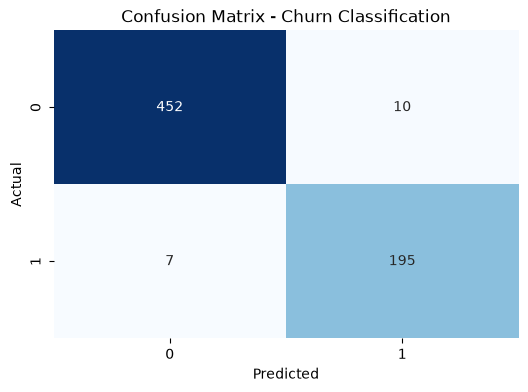

In [5]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_ch_test, y_ch_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Churn Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



Feature Importances (Churn Model):
                   Feature  Importance
1         predicted_amount    0.293766
0  predicted_duration_mins    0.256061
5              vehicle_age    0.203168
7                  mileage    0.113894
2               service_id    0.062538
3               base_price    0.036587
4      base_duration_hours    0.027802
6     vehicle_type_encoded    0.006185


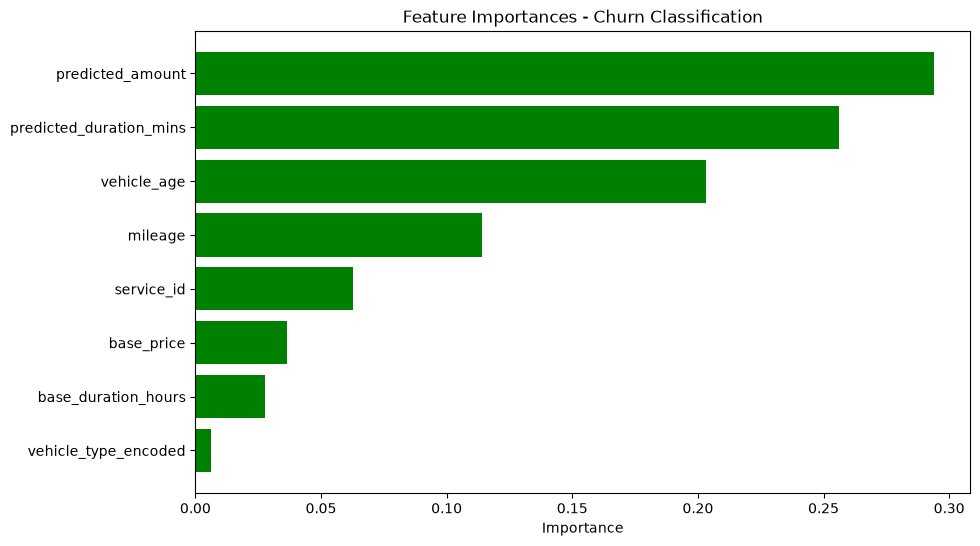

In [6]:
# Feature Importances for Churn
importances_ch = rf_churn.feature_importances_
feat_imp_ch = pd.DataFrame({'Feature': features_churn, 'Importance': importances_ch}).sort_values(by='Importance', ascending=False)
print("\nFeature Importances (Churn Model):")
print(feat_imp_ch)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_ch['Feature'], feat_imp_ch['Importance'], color='green')
plt.gca().invert_yaxis()
plt.title('Feature Importances - Churn Classification')
plt.xlabel('Importance')
plt.show()


In [7]:
import joblib
joblib.dump(rf_churn, 'exported/churn_model.pkl')
print("Exported: churn_model.pkl")


Exported: churn_model.pkl
